---

# COMBO CHARTS

---

>---
>You can create a **combo chart** by specifying different chart types in a dual axis plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)

df = (df
    .assign(state = df.region_name.str[-2:],
            region_name = df.region_name.str[:-11])
    .query("state == ['CA'] and region_name == 'San Francisco'")
    .groupby('period_begin').agg({'inventory':'sum',
                                 'median_active_list_price':'sum'})
    .resample('YE').sum().round()
)

df.head(6)

,inventory,median_active_list_price
period_begin,,
2017-12-31,37305.0,66290277.0
2018-12-31,41263.0,72005935.0
2019-12-31,41934.0,76429973.0
2020-12-31,71483.0,72317704.0
2021-12-31,62844.0,68568869.0
2022-12-31,20701.0,21984281.0


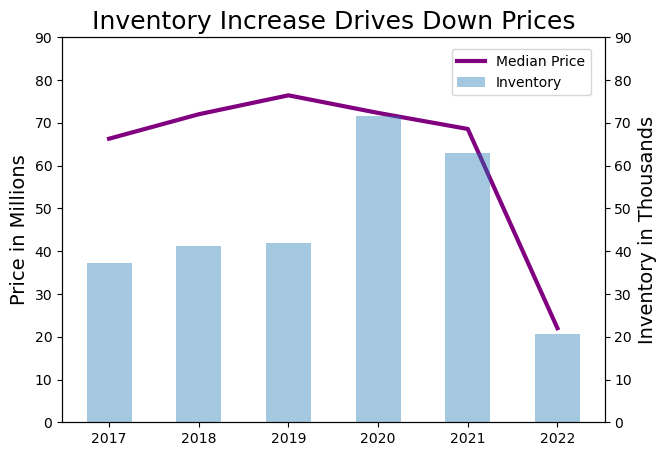

In [3]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

ax.plot(df.index.year, df.median_active_list_price/1e6, label='Median Price',
        color='purple', linestyle='-', linewidth=3)
ax.set_title('Inventory Increase Drives Down Prices', fontsize=18)
ax.set_ylabel('Price in Millions', fontsize=14)
ax.set_ylim(0, 90)

ax2 = ax.twinx()
ax2.bar(x=df.index.year, height=df.inventory/1e3, label='Inventory',
        width=0.5, alpha=0.4)
ax2.set_ylabel('Inventory in Thousands', fontsize=14)
ax2.set_ylim(0, 90)

fig.legend(bbox_to_anchor=(0.89, 0.87))

plt.show()

<br><br>

---

## LABORATORY

In [4]:
lab = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)

lab = (lab
    .query("region_name.str.contains('San Diego')")
    .groupby('period_begin').agg({'inventory':'sum', 
                                  'median_active_list_price':'sum'})
)
lab

,inventory,median_active_list_price
period_begin,,
2017-01-02,5468.0,618570.8
2017-01-09,5493.0,621737.5
2017-01-16,5520.0,625820.8
2017-01-23,5546.0,629491.6
2017-01-30,5581.0,632824.0
...,...,...
2022-03-28,3120.0,901649.6
2022-04-04,3291.0,902899.8
2022-04-11,3449.0,902899.8


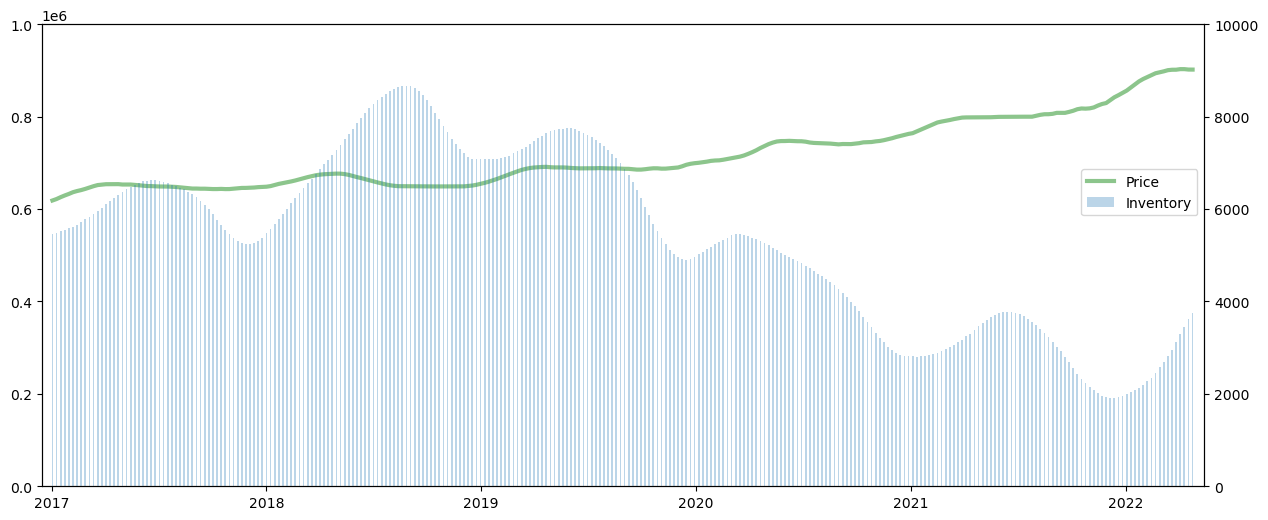

In [5]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)

ax.plot(lab.median_active_list_price, color='green',
        linewidth=3, alpha=0.45, label='Price')
ax.set_ylim(0, 1e6)
ax.set_xlim(pd.Timestamp('2016-12-15'), pd.Timestamp('2022-05-15'))

ax2 = ax.twinx()
ax2.bar(lab.index, lab.inventory, width=3,
        alpha=0.3, label='Inventory')
ax2.set_ylim(0, 10000)

fig.legend(bbox_to_anchor=(0.9, 0.65))


plt.show()

In [6]:
lab2 = lab.copy()
lab2 = lab2.resample('QE').sum().round()
lab2

,inventory,median_active_list_price
period_begin,,
2017-03-31,74114.0,8290116.0
2017-06-30,83647.0,8478529.0
2017-09-30,82876.0,8401624.0
2017-12-31,70673.0,8386070.0
2018-03-31,79586.0,8585456.0
2018-06-30,97731.0,8739857.0
2018-09-30,111012.0,8473323.0
2018-12-31,105908.0,9098400.0
2019-03-31,86238.0,8080177.0


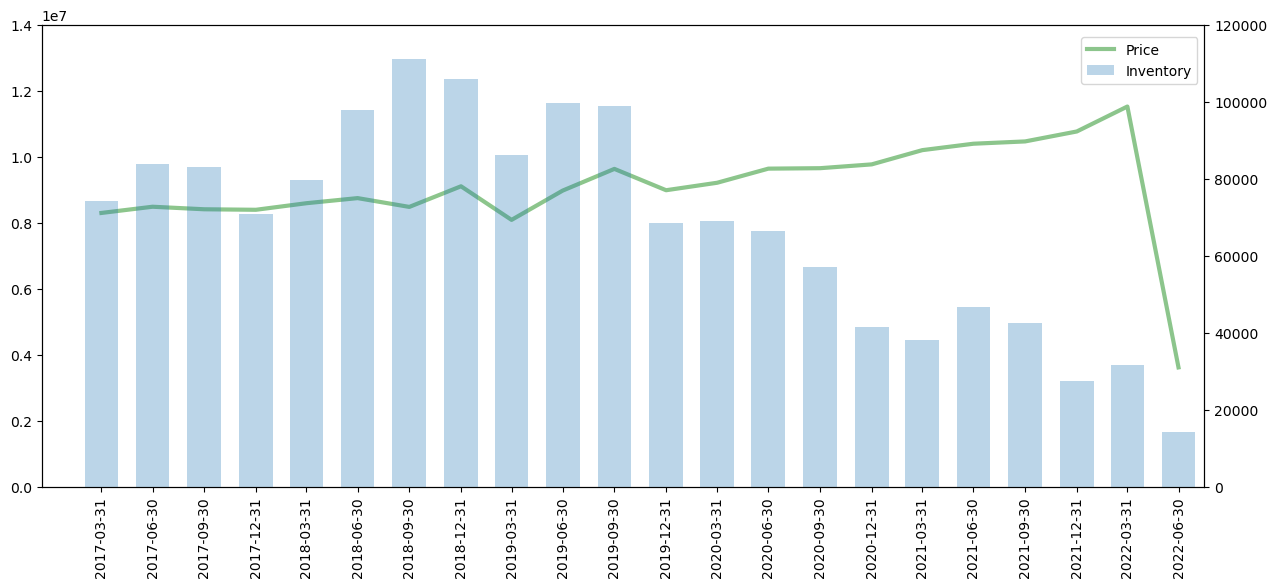

In [7]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)

ax.plot(lab2.median_active_list_price, color='green',
        linewidth=3, alpha=0.45, label='Price')
ax.set_ylim(0, 14e6)
ax.set_xlim(pd.Timestamp('2016-12-15'), pd.Timestamp('2022-08-15'))
ax.set_xticks(lab2.index[:])
plt.xticks(rotation=90)

ax2 = ax.twinx()
ax2.bar(lab2.index, lab2.inventory, width=60,
        alpha=0.3, label='Inventory')
ax2.set_ylim(0, 120000)
ax2.set_xticks(lab2.index[:])

fig.legend(bbox_to_anchor=(0.9, 0.87))


plt.show()